Loaded model: models/frf_model_full.pt
Feature tokens: ['f', 'damage']


/var/folders/41/v78ybjmx7vx3_5kr7kvcbk84h7cx3s/T/ipykernel_2009/1419118695.py:347: RuntimeWarning: Mean of empty slice
  mean_pred[cond] = np.nanmean(p, axis=0)


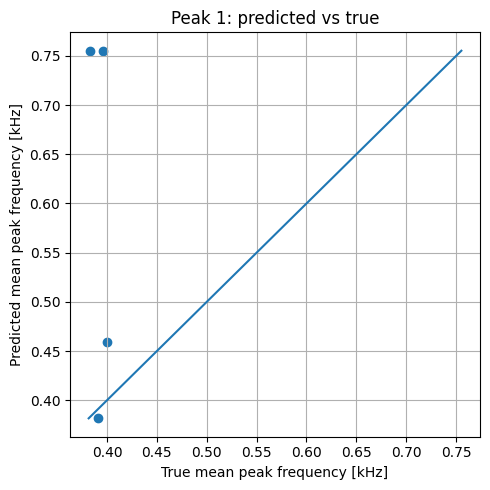

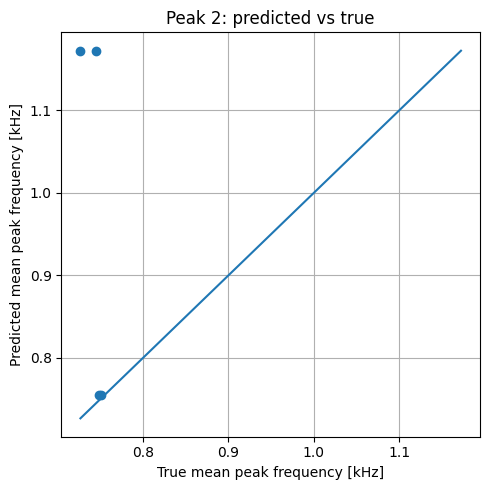

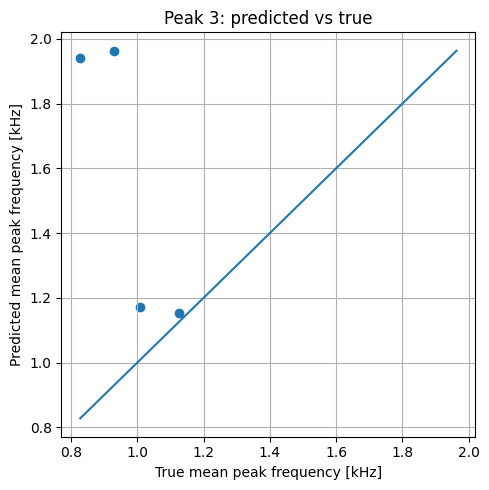

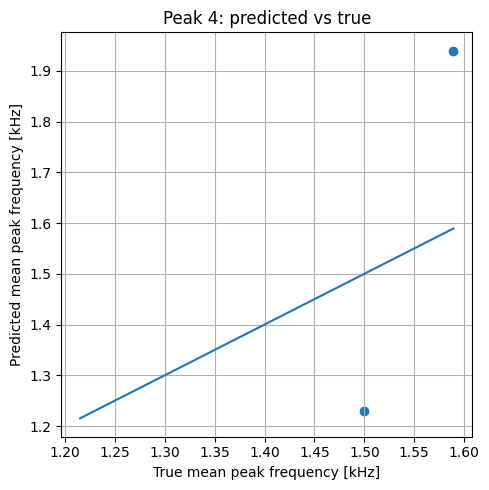

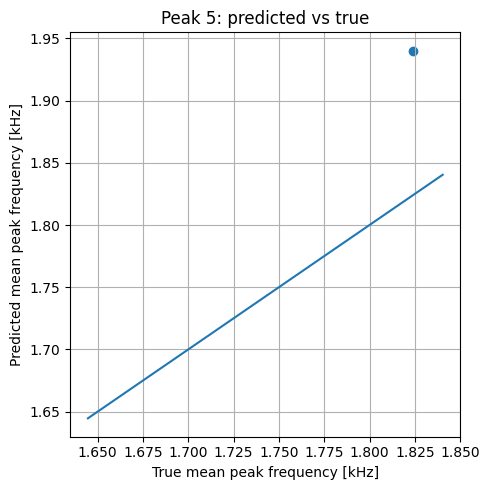


Resonator 0 symbolic expression:
-0.158954009413719/((omega - 0.63404)**2 - 0.281160324811935)



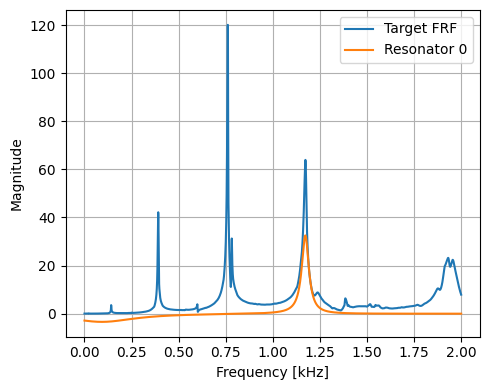


Resonator 1 symbolic expression:
-0.0216555073857307/((omega - 1.3486)**2 - 0.351539850234985)



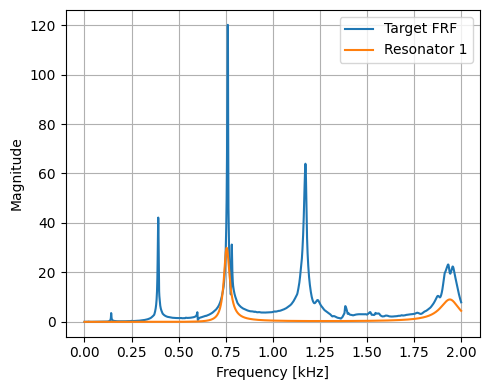


Resonator 2 symbolic expression:
-1.08142387866974/((-0.28149*d + omega + 0.06775)**2 + 0.105734668672085)



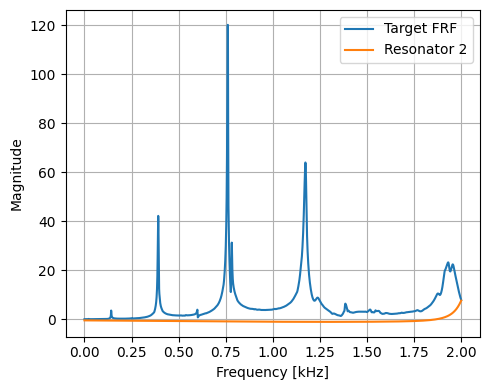


Resonator 3 symbolic expression:
0.190554425120354/((0.3118*d + omega - 0.77238)**2 - 0.147278621792793)



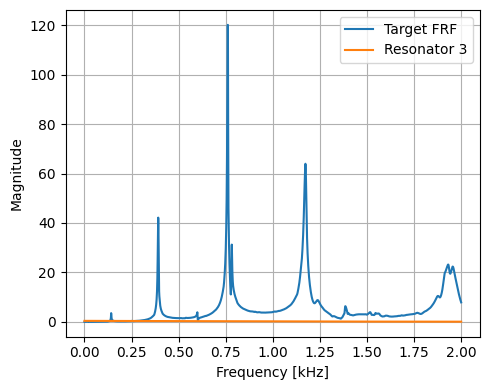


Resonator 4 symbolic expression:
-0.302526772022247/((0.38243*d - omega)**2 - 0.0621898770332336)



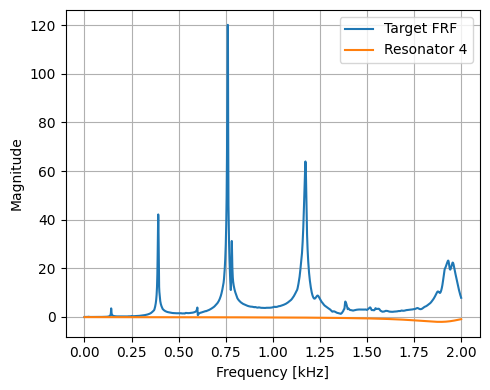


Resonator 5 symbolic expression:
-0.432110846042633/((0.00069*d**4 - omega)**2 - 1.36442506313324)



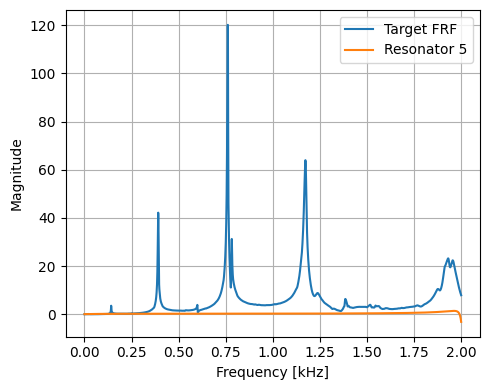

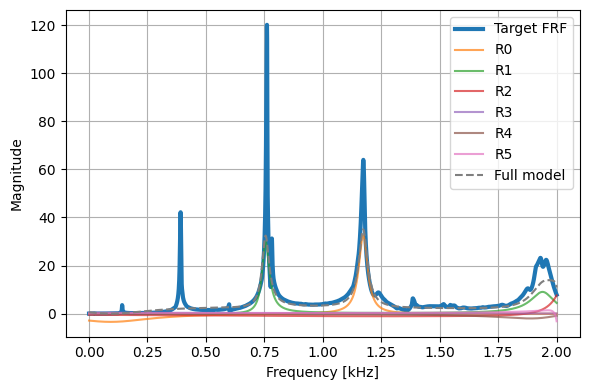

In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List

import dill
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import sympy as sp


# ============================================================
# CONFIG
# ============================================================

N_PEAKS = 5

DAMAGE_LEVEL = {
    "healthy": 0.0,
    "damage_2.96": 2.96,
    "damage_5.92": 5.92,
    "damage_8.87": 8.87,
}

ROOT = Path.cwd()
DATA = ROOT / "frf_data"

FRF_FOLDERS = {
    "healthy": DATA / "1-Beam_healthy",
    "damage_2.96": DATA / "2-Beam_damage_2.96",
    "damage_5.92": DATA / "3-Beam_damage_5.92",
    "damage_8.87": DATA / "4-Beam_damage_8.87",
}

MODEL_PATH = Path("models/frf_model_full.pt")

device = torch.device("cpu")


# ============================================================
# Load model
# ============================================================

ckpt = torch.load(
    MODEL_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

FEATURE_TOKENS: List[str] = ckpt["feature_tokens"]

print("Loaded model:", MODEL_PATH)
print("Feature tokens:", FEATURE_TOKENS)


# ============================================================
# Robust FRF reader
# ============================================================

_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")


def read_frf_txt(path: Path):

    text = path.read_bytes().decode("latin-1", errors="ignore")

    f_list, m_list, p_list = [], [], []

    for line in text.splitlines():

        line = line.strip()
        if not line:
            continue

        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue

        f = float(nums[0])
        mag = float(nums[1])
        ph = float(nums[2])

        if not (np.isfinite(f) and np.isfinite(mag) and np.isfinite(ph)):
            continue

        f_list.append(f)
        m_list.append(mag)
        p_list.append(ph)

    f = np.asarray(f_list)
    mag = np.asarray(m_list)
    ph = np.asarray(p_list)

    idx = np.argsort(f)

    return f[idx], mag[idx], ph[idx]


# ============================================================
# Feature builder
# ============================================================

def db_to_linear_mag(mag_db: np.ndarray):
    return np.power(10.0, mag_db / 20.0)


def build_feature_matrix(f, mag_db, ph_deg, cond):

    phi = np.deg2rad(ph_deg)

    sinp = np.sin(phi)
    cosp = np.cos(phi)

    damage = DAMAGE_LEVEL[cond]

    feature_bank = {

        "f": (f / 1000.0).astype(np.float32),
        "sin_phase": sinp.astype(np.float32),
        "cos_phase": cosp.astype(np.float32),
        "damage": np.full_like(f, damage, dtype=np.float32),

    }

    X = np.concatenate(
        [feature_bank[t].reshape(-1, 1) for t in FEATURE_TOKENS],
        axis=1,
    ).astype(np.float32)

    y = db_to_linear_mag(mag_db).astype(np.float32)

    return X, y


# ============================================================
# Model prediction
# ============================================================

def predict_curve(fp: Path, cond: str):

    f, mag_db, ph_deg = read_frf_txt(fp)

    X, y_true = build_feature_matrix(f, mag_db, ph_deg, cond)

    with torch.no_grad():

        Xc = torch.from_numpy(X).float().to(device)

        pred = model(Xc).real

        y_pred = pred.detach().cpu().numpy().reshape(-1)

    f_idx = FEATURE_TOKENS.index("f")

    freq = X[:, f_idx]

    return freq, y_true, y_pred


# ============================================================
# Resonator decomposition
# ============================================================

def predict_resonators(fp: Path, cond: str):

    f, mag_db, ph_deg = read_frf_txt(fp)

    X, y_true = build_feature_matrix(f, mag_db, ph_deg, cond)

    Xc = torch.from_numpy(X).float().to(device)

    with torch.no_grad():

        full_pred = model(Xc).real

        full_pred = full_pred.detach().cpu().numpy().reshape(-1)

        resonator_outputs = []

        for r in model.resonators:

            y_r = r(Xc).real

            resonator_outputs.append(
                y_r.detach().cpu().numpy().reshape(-1)
            )

    f_idx = FEATURE_TOKENS.index("f")

    freq = X[:, f_idx]

    return freq, y_true, full_pred, resonator_outputs


# ============================================================
# Symbolic input builder
# ============================================================

def feature_symbols():

    omega = sp.Symbol("omega")
    phi = sp.Symbol("phi")
    d = sp.Symbol("d")

    name_map = {
        "f": omega,
        "sin_phase": sp.sin(phi),
        "cos_phase": sp.cos(phi),
        "damage": d,
    }

    return [name_map[t] for t in FEATURE_TOKENS]


# ============================================================
# Plot resonators + symbolic expressions
# ============================================================

def plot_resonators(fp: Path, cond: str):

    f, y_true, full_pred, resonators = predict_resonators(fp, cond)

    sym_inputs = feature_symbols()

    aux_inputs = [s for s in sym_inputs if s != sym_inputs[FEATURE_TOKENS.index("f")]]

    omega = sp.Symbol("omega")

    for i, (r, block) in enumerate(zip(resonators, model.resonators)):

        h = block.eql.get_symbolic_expression(
            aux_inputs,
            rounding_decimals=5,
            use_imag=False,
        )

        A = float(block.A.real.detach().cpu())
        gamma = float(block.gamma.real.detach().cpu())

        expr = A / ((omega - h) ** 2 + gamma)
        expr = sp.simplify(expr)

        print("\n==============================")
        print(f"Resonator {i} symbolic expression:")
        print(expr)
        print("==============================\n")

        plt.figure(figsize=(5,4))
        plt.plot(f, y_true, label="Target FRF")
        plt.plot(f, r, label=f"Resonator {i}")
        plt.xlabel("Frequency [kHz]")
        plt.ylabel("Magnitude")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(6,4))

    plt.plot(f, y_true, label="Target FRF", linewidth=3)

    for i, r in enumerate(resonators):
        plt.plot(f, r, label=f"R{i}", alpha=0.7)

    plt.plot(f, full_pred, "--", label="Full model")

    plt.xlabel("Frequency [kHz]")
    plt.ylabel("Magnitude")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()


# ============================================================
# Peak detection
# ============================================================

def detect_top_peaks(freq, y, n=N_PEAKS):

    idx, _ = find_peaks(y)

    if len(idx) == 0:
        return np.full(n, np.nan)

    amps = y[idx]

    order = np.argsort(amps)[::-1]

    idx = idx[order[:n]]

    freqs = freq[idx]

    freqs = np.sort(freqs)

    if len(freqs) < n:
        freqs = np.pad(freqs, (0, n-len(freqs)), constant_values=np.nan)

    return freqs


# ============================================================
# Collect peaks
# ============================================================

true_peaks_by_damage: Dict[str, List[np.ndarray]] = {}
pred_peaks_by_damage: Dict[str, List[np.ndarray]] = {}

for cond, folder in FRF_FOLDERS.items():

    true_peaks_by_damage[cond] = []
    pred_peaks_by_damage[cond] = []

    for fp in sorted(folder.glob("*.txt")):

        f, y_true, y_pred = predict_curve(fp, cond)

        p_true = detect_top_peaks(f, y_true)
        p_pred = detect_top_peaks(f, y_pred)

        true_peaks_by_damage[cond].append(p_true)
        pred_peaks_by_damage[cond].append(p_pred)


# ============================================================
# Mean peak frequencies
# ============================================================

mean_true = {}
mean_pred = {}

for cond in FRF_FOLDERS.keys():

    t = np.vstack(true_peaks_by_damage[cond])
    p = np.vstack(pred_peaks_by_damage[cond])

    mean_true[cond] = np.nanmean(t, axis=0)
    mean_pred[cond] = np.nanmean(p, axis=0)


# ============================================================
# Scatter plots PER PEAK
# ============================================================

for peak_idx in range(N_PEAKS):

    true_vals = []
    pred_vals = []

    for cond in FRF_FOLDERS.keys():

        true_vals.append(mean_true[cond][peak_idx])
        pred_vals.append(mean_pred[cond][peak_idx])

    true_vals = np.array(true_vals)
    pred_vals = np.array(pred_vals)

    plt.figure(figsize=(5,5))

    plt.scatter(true_vals, pred_vals)

    min_v = min(true_vals.min(), pred_vals.min())
    max_v = max(true_vals.max(), pred_vals.max())

    plt.plot([min_v, max_v], [min_v, max_v])

    plt.xlabel("True mean peak frequency [kHz]")
    plt.ylabel("Predicted mean peak frequency [kHz]")

    plt.title(f"Peak {peak_idx+1}: predicted vs true")

    plt.grid(True)
    plt.tight_layout()

    plt.show()


# ============================================================
# Resonator visualization
# ============================================================

example_file = sorted(FRF_FOLDERS["damage_5.92"].glob("*.txt"))[0]

plot_resonators(example_file, "damage_5.92")